### Import Libraries

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [198]:
df=pd.read_csv('/content/drive/MyDrive/Food_Delivery_Time_Prediction.csv')

### Data Inspection

In [200]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [201]:
# Checking the Shape of Dataset
rows,cols=df.shape
print(f'Rows:{rows}, Columns:{cols}')

Rows:50000, Columns:24


- Shape Attribute, It provides the rows and column count od Dataset

In [202]:
df.columns # Features in Dataset

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

- df.columns extract the features in Dataset

In [203]:
# Selecting only numeric columns
num_cols=df.select_dtypes(include='number').columns
num_cols

Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals',
       'Average_Speed_kmph', 'Time_taken_min'],
      dtype='object')

- Filters the Features having datatype int or float

In [204]:
# Selecting only text/categorical columns
df.select_dtypes(include='object').columns

Index(['Order_ID', 'Order_Date', 'Day_of_Week', 'Weather', 'Pickup_Zone',
       'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load',
       'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority'],
      dtype='object')

- Filter the text/categorical features

In [205]:
# Datatypes of Each Column in DataFrame
df.dtypes

,0
Order_ID,object
Order_Date,object
Order_Hour,int64
Day_of_Week,object
Is_Weekend,int64
Is_Festival,int64
Weather,object
Pickup_Zone,object
Dropoff_Zone,object
Vehicle_Type,object


- df.dtypes provides the Datatype of each Feature

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

- df.info() provides the Information of Dataset containing range,columns with not null count and datatypes,memory usage.

- It provides the overall information,structure of Data

In [207]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


- describe method provides the statistical information of the Data.

In [208]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Order_Hour,0
Day_of_Week,0
Is_Weekend,0
Is_Festival,0
Weather,0
Pickup_Zone,0
Dropoff_Zone,0
Vehicle_Type,0


- df.isnull().sum() provides the count of null in each column.

In [209]:
df.duplicated().sum()

np.int64(0)

- df.isnull().sum() provides the count of duplicates presented in each column.

### Data Cleaning

In [210]:
# removing unnecessary columns
df = df.drop(columns=["Order_ID", "Order_Date"])

- Removed "Order_ID", "Order_Date" columns because they does not provide the meaningfull information to predict the model.

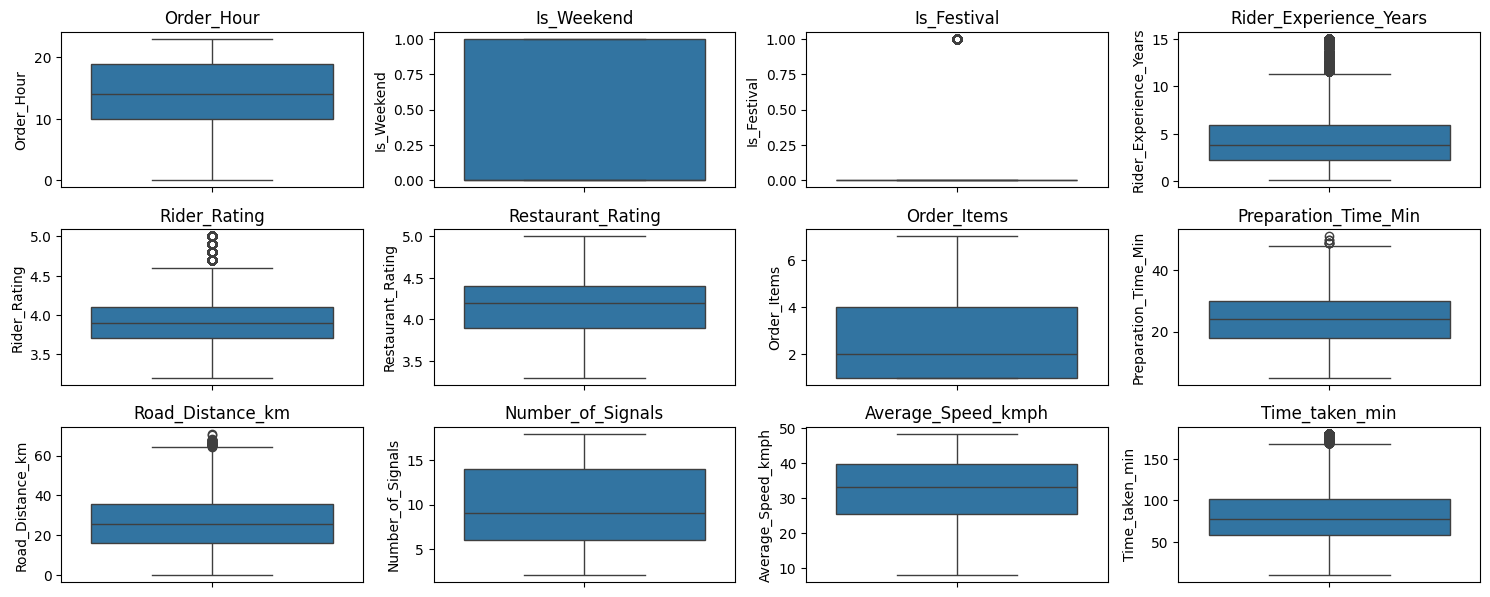

In [211]:
# Detecting Outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Data Distribution and Outliers Observation
- I created a boxplox plot for every numerical column, to visualize the distribution and Outliers in the Dataset.

- `Order_Hours` : Most order are between 10 to 20.So it does not have any Outliers.

- ` is_weekend` : Because this is a binary variable so it does not have any meaning information from box plot.
- `is_festival` : A boxplot can label a valid categorical/binary value as an "outlier" mathematically. So 1 is not an Outlier.
- `rider_experience_years` : So Many riders have experience in between 2 to 6 years.But in boxplot the are datapoints above 11 which are valid experience years. So we do not need to delete them.
- `Rider_Rating` : Most raiders have a rating approximately in between 3.7 to 4.2 . The are values above 4.6 which has flagged as an Outliers.But they are valid high ratings. No need to Remove.
-`Restaurant_Rating` : Most resturents are rated around 3.9 – 4.4.There aren't significant outliers.
- `Order_Items` : Most orders contains 1 to 4 items. There aren't significant outliers.
- `Preparation_Time_Min`: Most of the items takes prepration time around 20 to 30 minutes. Some of the datapoints above 50 flagged as an outlier.But the values are mostly valid because some items takes 50 min to 1hr to prepare
- `Road_Distance_km` : Most deliveries appear to be approximately
15 – 35 km. There are some extreme values which are roughly above 60, these are potential outliers.so delivery a food item for 60km is might be unusual.
-`Average_Speed_kmph` : No extreme values.The vechile average speed ranges between 25km/hr to 40km/hr.
-`Time_taken_min`:Most delivery times are around 50 to 100 minutes.There are some potential outliers which are roughly above 180 min.


## Final Conclusion:

- There are two feature which contains Potential Outliers they are
 `Road_Distance_km`
 `Time_taken_min`


In [212]:
Q1 = df["Road_Distance_km"].quantile(0.25)
Q3 = df["Road_Distance_km"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
upper_bound = Q3 + 1.5 * IQR

print("Upper Bound:", upper_bound)
distance_outliers = df[df["Road_Distance_km"] > upper_bound]

distance_outliers.shape

Q1: 16.33
Q3: 35.48
IQR: 19.15
Upper Bound: 64.205


(32, 22)

In [213]:
distance_outliers["Road_Distance_km"].sort_values()

,Road_Distance_km
290,64.25
39961,64.68
17698,64.69
10491,64.90
21692,64.93
33307,65.00
32587,65.15
4095,65.21
43909,65.22
40553,65.45


In [214]:
distance_outliers["Road_Distance_km"].describe()

,Road_Distance_km
count,32.000000
mean,66.484063
std,1.552164
min,64.250000
25%,65.217500
50%,66.310000
75%,67.560000
max,70.820000


In [215]:
distance_outliers["Road_Distance_km"].sort_values().to_list()

[64.25,
 64.68,
 64.69,
 64.9,
 64.93,
 65.0,
 65.15,
 65.21,
 65.22,
 65.45,
 65.57,
 65.63,
 65.7,
 66.17,
 66.3,
 66.31,
 66.31,
 66.33,
 66.45,
 66.45,
 66.85,
 66.98,
 67.11,
 67.54,
 67.62,
 67.73,
 67.74,
 67.74,
 67.9,
 68.34,
 70.42,
 70.82]

In [216]:
Q1 = df["Time_taken_min"].quantile(0.25)
Q3 = df["Time_taken_min"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Bound:", upper_bound)
time_outliers = df[
    df["Time_taken_min"] > upper_bound
]

print("Number of outliers:", len(time_outliers))


Q1: 58.0
Q3: 102.0
IQR: 44.0
Upper Bound: 168.0
Number of outliers: 2153


In [217]:
time_outliers["Time_taken_min"].value_counts().sort_index()

,count
Time_taken_min,
169,56
170,50
171,60
172,44
173,36
174,50
175,39
176,39
177,49


## Exploratory Data Analysis

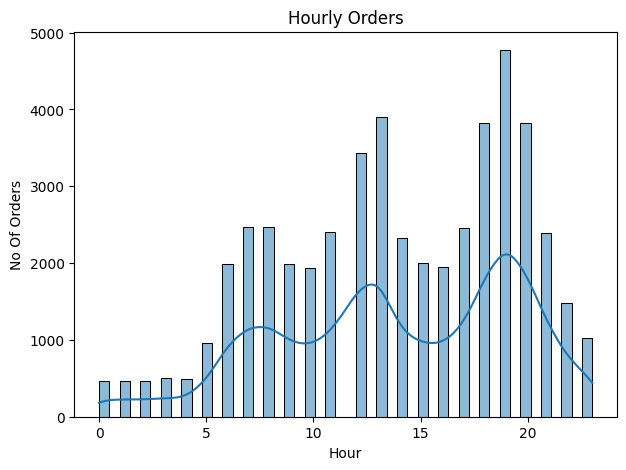

In [219]:
plt.figure(figsize=(7,5))
sns.histplot(df['Order_Hour'],kde=True)
plt.title('Hourly Orders')
plt.xlabel('Hour')
plt.ylabel('No Of Orders')
plt.show()

- Order volume is low during early morning hours, rises through the day, and peaks around 19:00 (7 PM).
- Orders remain high during the evening before declining sharply after 21:00, indicating evening is the busiest period.

/tmp/ipykernel_717/3109738095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


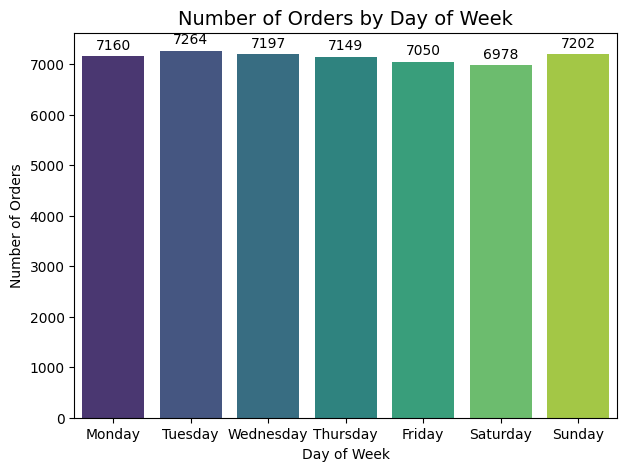

In [220]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df,
    x='Day_of_Week',
    palette='viridis',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of Orders by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

- Order volume is almost uniformly distributed across all seven days of the week
- Tuesday sees the highest overall order count

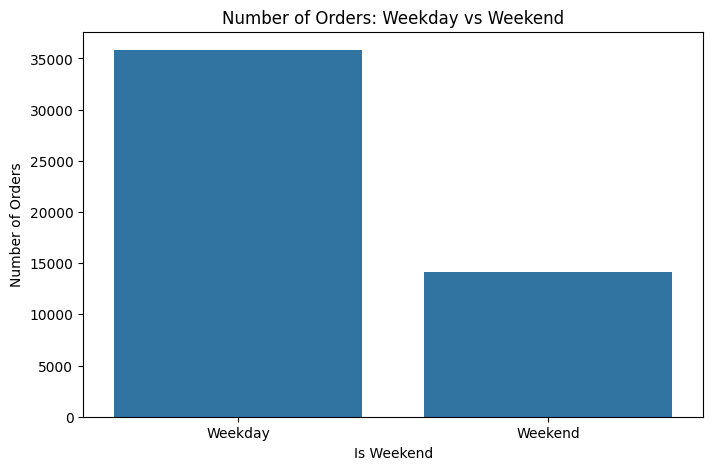

In [228]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Is_Weekend')
plt.title('Number of Orders: Weekday vs Weekend')
plt.xlabel('Is Weekend')
plt.ylabel('Number of Orders')
plt.xticks(ticks=[0, 1], labels=['Weekday', 'Weekend'])
plt.show()

- Weekdays (Is_Weekend = 0) account for the majority of total orders , whereas weekends make up the remaining.

/tmp/ipykernel_717/2676286147.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


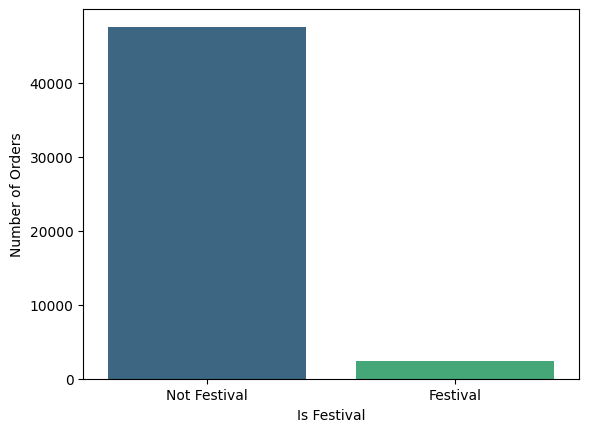

In [222]:
sns.countplot(
    data=df,
    x='Is_Festival', palette='viridis')
plt.xlabel('Is Festival')
plt.ylabel('Number of Orders')
plt.xticks([0,1],['Not Festival','Festival'])
plt.show()

- Non-festival days make up the vast majority of dataset orders.
- Festival days account for only ~2,500 orders.

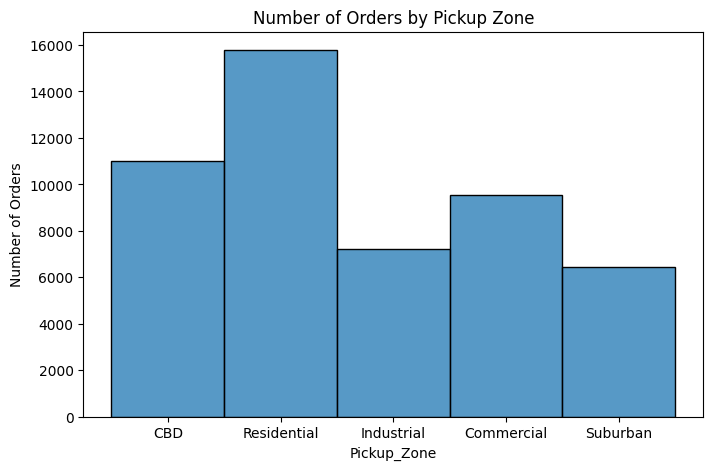

In [224]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,
             x='Pickup_Zone')
plt.title('Number of Orders by Pickup Zone')
plt.xlabel('Pickup_Zone')
plt.ylabel('Number of Orders')
plt.show()

- Residential zones account for the highest volume of order pickups.
- CBD (Central Business District) is the second highest pickup area.
- ndustrial and Suburban zones see significantly lower pickup demand.

/tmp/ipykernel_717/3318562902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


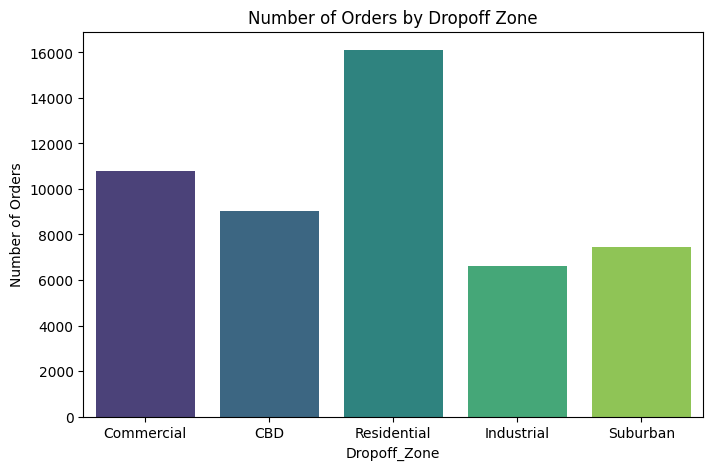

In [227]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,
             x='Dropoff_Zone', palette='viridis',)
plt.title('Number of Orders by Dropoff Zone')
plt.xlabel('Dropoff_Zone')
plt.ylabel('Number of Orders')
plt.show()

- Primary Destination: Residential zones account for the highest volume of order dropoffs (~16,000 orders).

- Secondary Destination: CBD (Central Business District) is the second highest dropoff area (~11,000 orders).

- Lower Volume Destinations: Industrial and Suburban zones see significantly lower dropoff demand (~6,500–7,500 orders each).

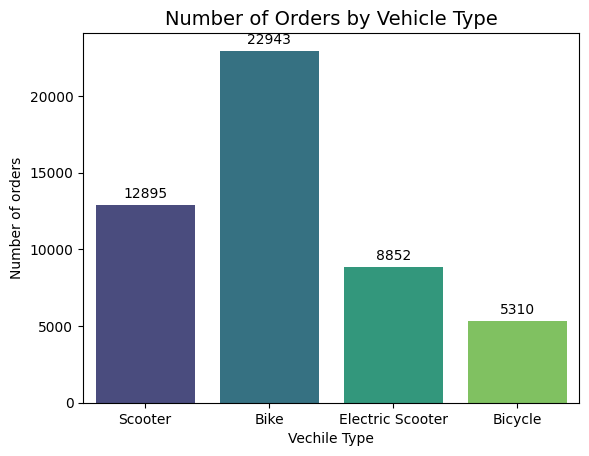

In [130]:
ax=sns.countplot(data=df,
              x='Vehicle_Type',
              palette='viridis',
              hue='Vehicle_Type')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('Number of Orders by Vehicle Type', fontsize=14)
plt.xlabel('Vechile Type')
plt.ylabel('Number of orders')
plt.show()

- Bike has the highest number of orders (22,943).
- Scooter is the second most-used (12,895).
- Electric Scooter has 8,852 orders.
- Bicycle has the lowest number of orders (5,310).
- Overall, two-wheelers dominate the deliveries, with Bikes being the most preferred vehicle.

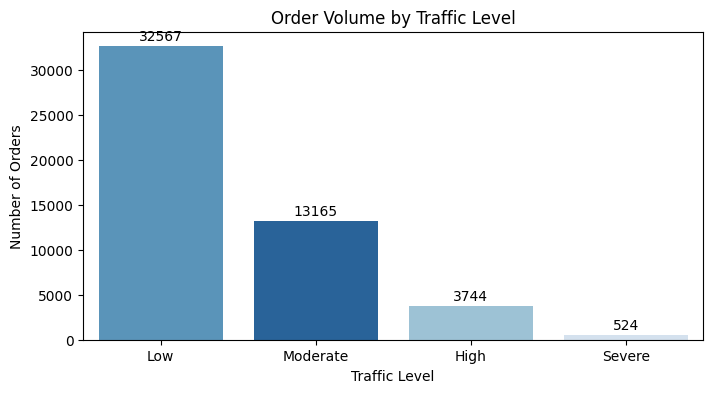

In [131]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='Traffic_Level', order=df['Traffic_Level'].value_counts().index, palette='Blues_r', hue='Traffic_Level', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)
plt.title('Order Volume by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Number of Orders')
plt.show()

- Low traffic has the highest order volume (32,567 orders).
- Moderate traffic has 13,165 orders.
- High traffic has only 3,744 orders.
- Severe traffic has the lowest volume (524 orders).
- Most deliveries occur under Low traffic conditions.

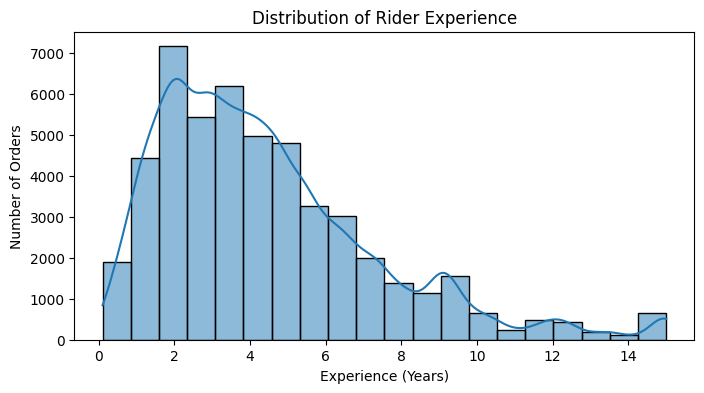

In [132]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Rider_Experience_Years', kde=True, bins=20)
plt.title('Distribution of Rider Experience')
plt.xlabel('Experience (Years)')
plt.ylabel('Number of Orders')
plt.show()

- Most riders have 2–5 years of experience.
- Distribution is right-skewed, with fewer highly experienced riders.
- Very few riders have 10+ years of experience.

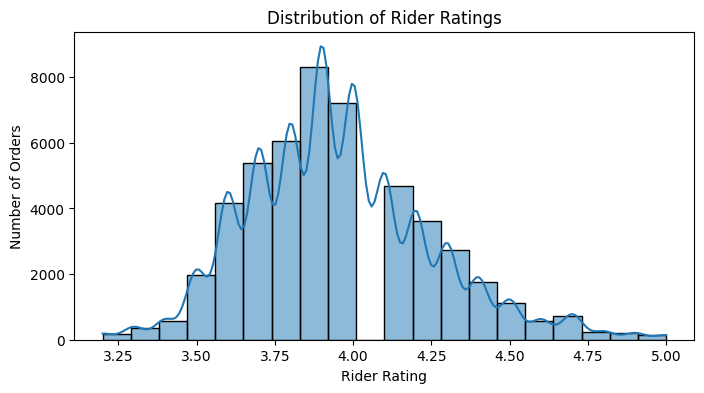

In [133]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Rider_Rating', kde=True, bins=20)
plt.title('Distribution of Rider Ratings')
plt.xlabel('Rider Rating')
plt.ylabel('Number of Orders')
plt.show()

- Ratings are concentrated around 3.7–4.2.
- Most riders have ratings close to 4.0.
- Very low (<3.5) and very high (>4.7) ratings are relatively rare.

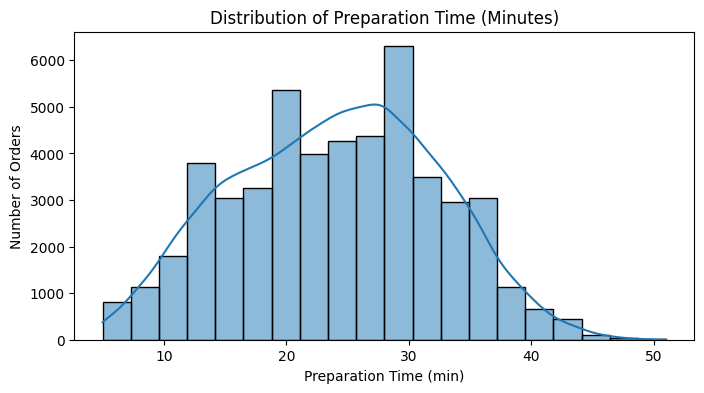

In [134]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Preparation_Time_Min', kde=True, bins=20)
plt.title('Distribution of Preparation Time (Minutes)')
plt.xlabel('Preparation Time (min)')
plt.ylabel('Number of Orders')
plt.show()

- Most preparation times are around 15–35 minutes.
- Peak concentration is around 25–30 minutes.
- Higher preparation times above 40 minutes are relatively uncommon.

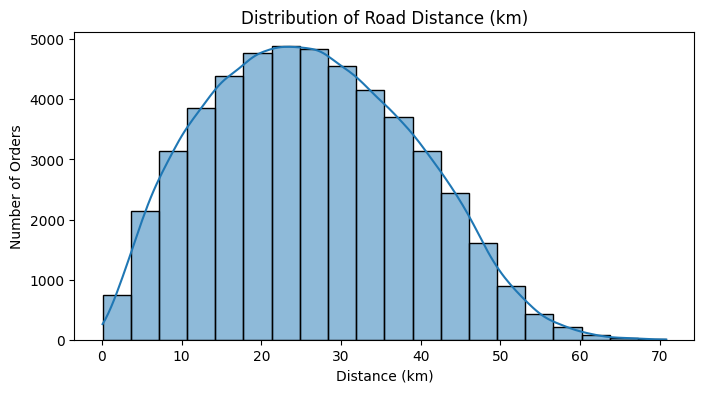

In [135]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Road_Distance_km', kde=True, bins=20)
plt.title('Distribution of Road Distance (km)')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Orders')
plt.show()

- Most deliveries fall around 15–40 km.
- Distribution is right-skewed.
- Very long distances (50+ km) are relatively rare.

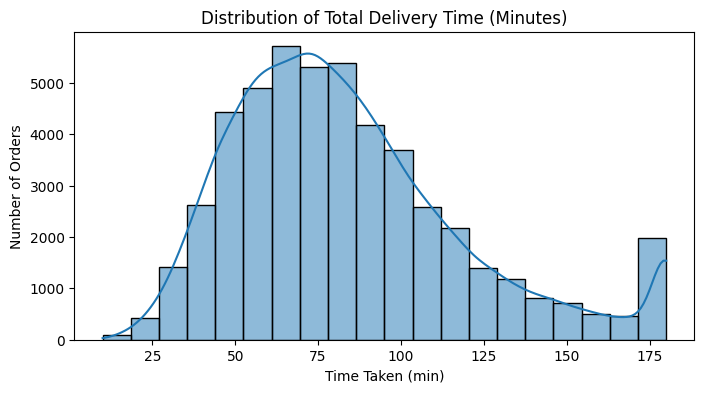

In [136]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Time_taken_min', kde=True, bins=20)
plt.title('Distribution of Total Delivery Time (Minutes)')
plt.xlabel('Time Taken (min)')
plt.ylabel('Number of Orders')
plt.show()

- More Number of order will take 50 to 90 mins delivery time.
- Approximately less than 500 Orders will take 25 mins to deliver.
- Nearly 2000 orders will take 180 mins to deliver.

### Features Vs Target

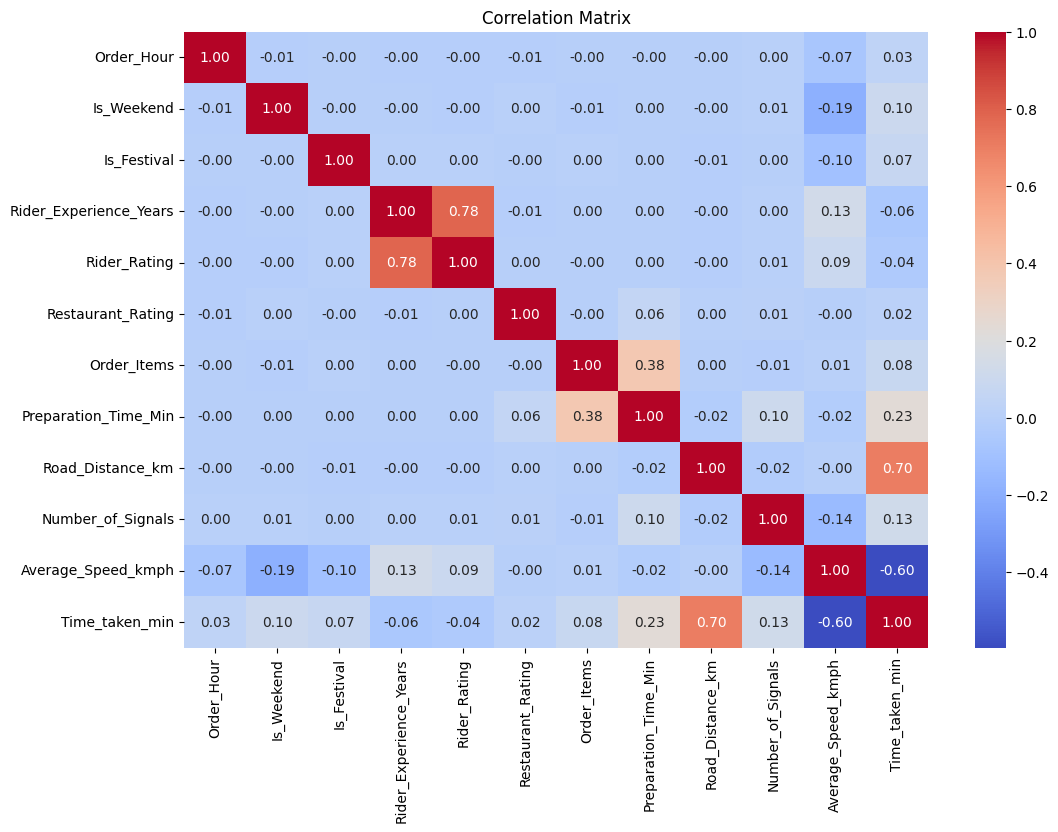

In [229]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

- Road distance has a strong positive correlation (0.70) with delivery time, while average speed has a strong negative correlation (-0.60). Preparation time shows a weak positive relationship (0.23); other numerical features have little correlation with delivery time.
- Rider_Experience_Years ↔ Rider_Rating: 0.78 → strong positive correlation; more experienced riders tend to have higher ratings.

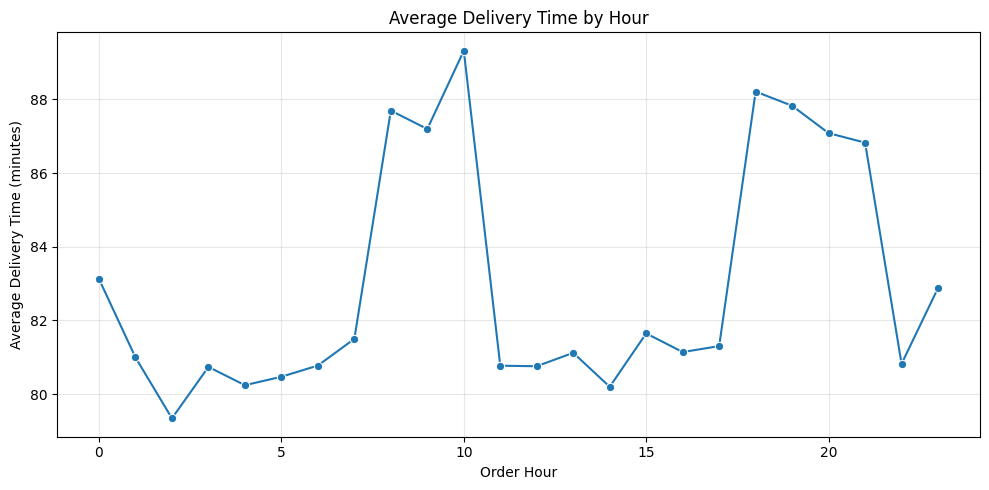

In [190]:
hourly_time = (
    df.groupby("Order_Hour", as_index=False)["Time_taken_min"]
      .mean()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_time,
    x="Order_Hour",
    y="Time_taken_min",
    marker="o"
)

plt.title("Average Delivery Time by Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Average delivery time varies noticeably by hour.
- 10 AM has the highest average delivery time (~89 min).
- 18–21 hours also show relatively high delivery times (~87–88 min).
- 2 AM has the lowest average (~79 min).
- Delivery time is generally higher during morning and evening peak periods.

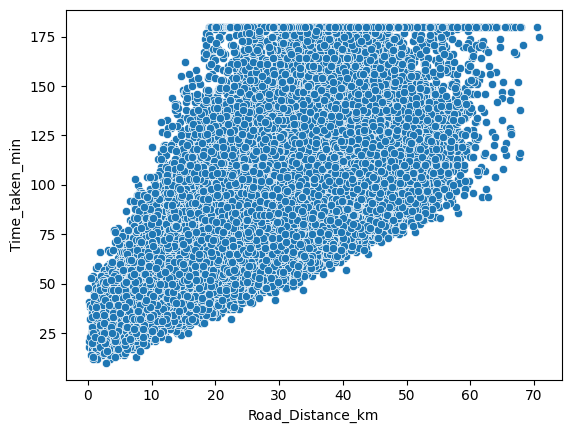

In [138]:
sns.scatterplot(data=df,x="Road_Distance_km",y="Time_taken_min")
plt.show()

- Around 0–10 km → delivery time is mostly around 15–60 min
- Around 20–40 km → many deliveries are around 50–130 min
- Around 50–70 km → delivery times are frequently 90–170+ min

- Longer delivery distance generally results in longer delivery time.

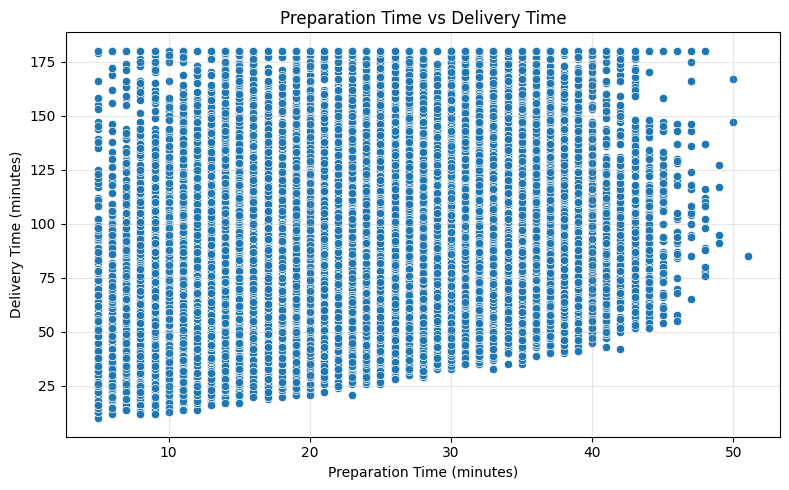

In [191]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Preparation_Time_Min",
    y="Time_taken_min"
)

plt.title("Preparation Time vs Delivery Time")
plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Preparation time shows a positive relationship with delivery time.
- This indicates that preparation time contributes to delivery duration but other factors, such as distance, traffic and speed, also play an important role.

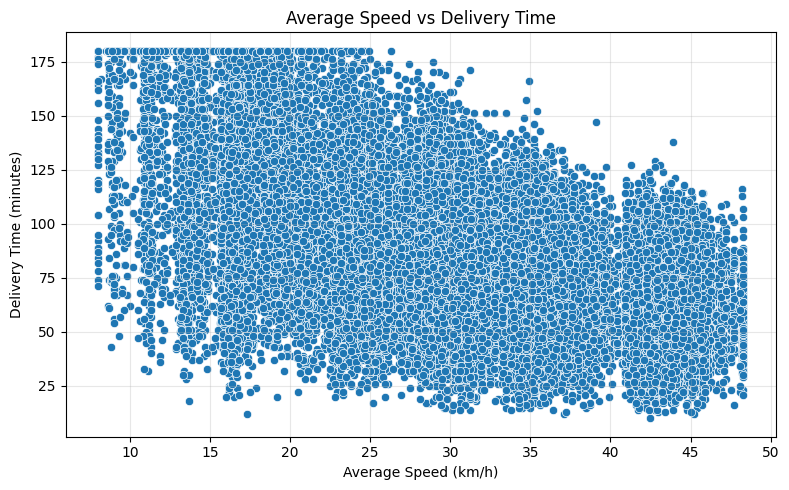

In [192]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Average_Speed_kmph",
    y="Time_taken_min"
)

plt.title("Average Speed vs Delivery Time")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Delivery Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- As the Avg speed of vechile increase the delivery time decreases.


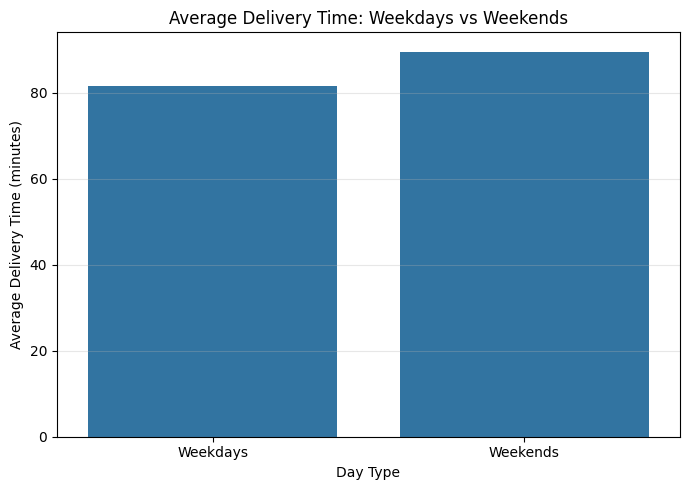

In [193]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Is_Weekend",
    y="Time_taken_min",
    errorbar=None
)

plt.title("Average Delivery Time: Weekdays vs Weekends")
plt.xlabel("Day Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks([0, 1], ["Weekdays", "Weekends"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- In weekend the time taken to deliver the order is higher than weekdays.


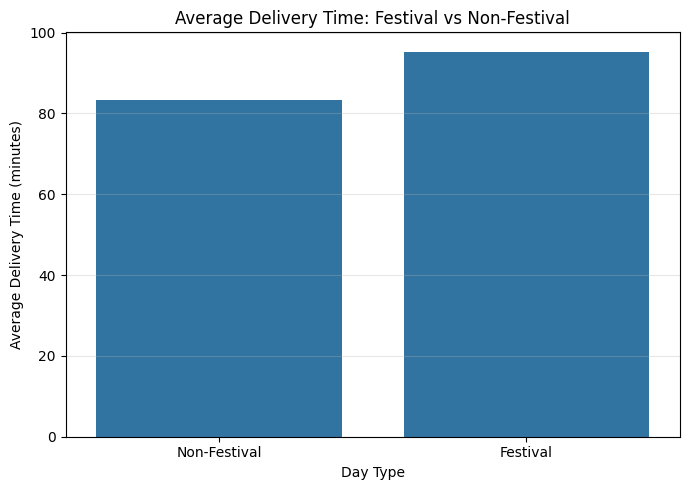

In [194]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Is_Festival",
    y="Time_taken_min",
    errorbar=None
)

plt.title("Average Delivery Time: Festival vs Non-Festival")
plt.xlabel("Day Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks([0, 1], ["Non-Festival", "Festival"])
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- During the festival days the time taken to deliver the order is higher than the Non Festival days.

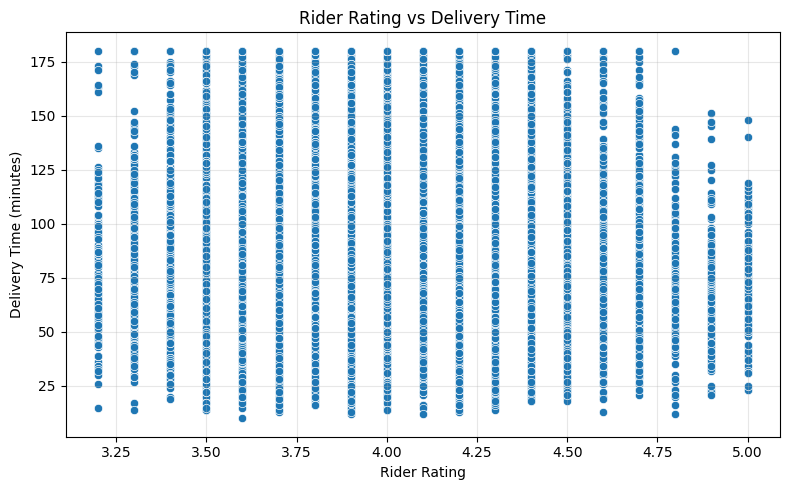

In [195]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rider_Rating",
    y="Time_taken_min"
)

plt.title("Rider Rating vs Delivery Time")
plt.xlabel("Rider Rating")
plt.ylabel("Delivery Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Rider rating does not have much relationship with the delivery time.
- But 5 star riders does not take more than 150 mins to deliver the food.


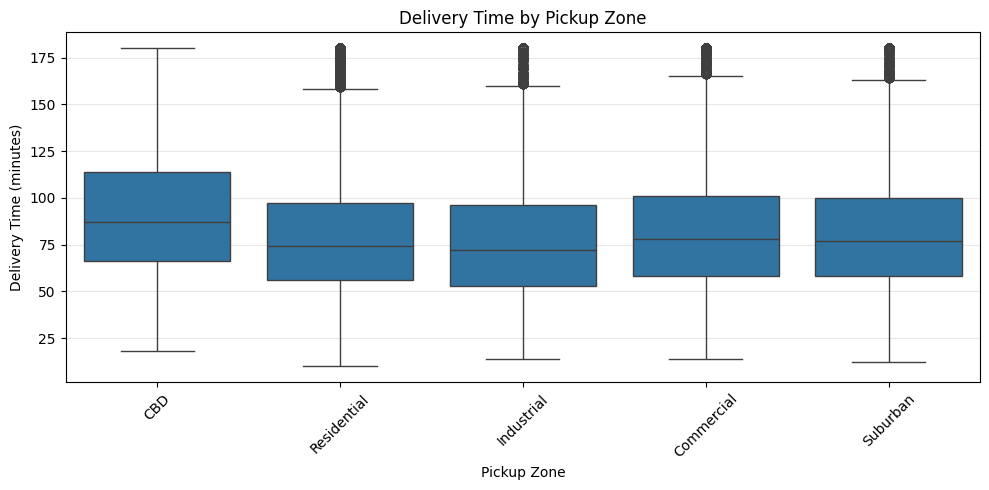

In [196]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Pickup_Zone",
    y="Time_taken_min"
)

plt.title("Delivery Time by Pickup Zone")
plt.xlabel("Pickup Zone")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Delivery time varies across distance categories, but the distributions overlap considerably. CBD deliveries tend to take longer, while the other categories show similar patterns with many high-time outliers.

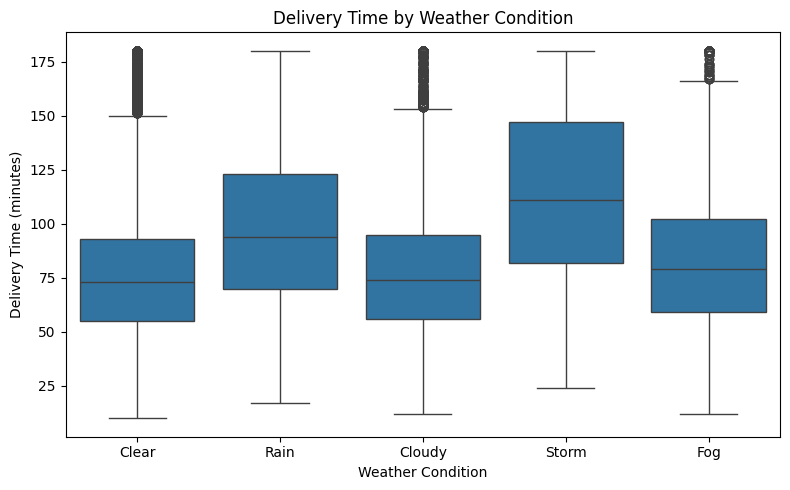

In [150]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Weather",
    y="Time_taken_min"
)

plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.show()

- Storm has the highest median delivery time, followed by Rain. Clear and Cloudy have lower medians, while Fog is intermediate.

- Weather conditions appear to affect delivery time, with Storm and Rain generally associated with longer delivery times.

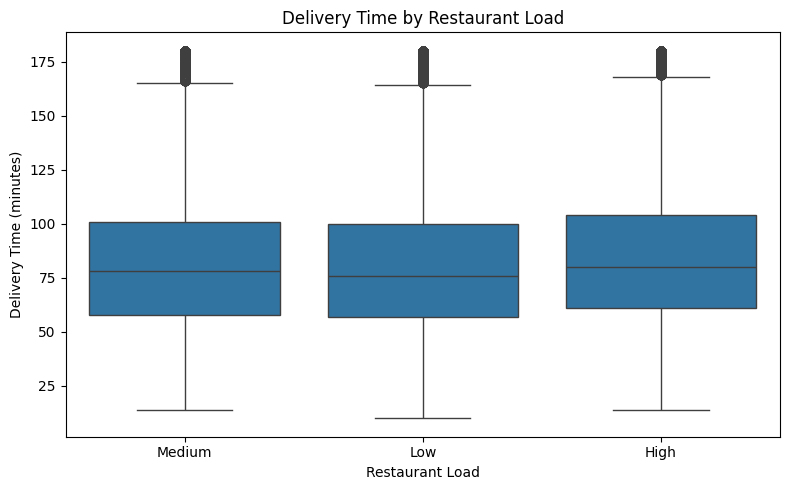

In [151]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Restaurant_Load",
    y="Time_taken_min"
)

plt.title("Delivery Time by Restaurant Load")
plt.xlabel("Restaurant Load")
plt.ylabel("Delivery Time (minutes)")


plt.tight_layout()
plt.show()

- Restaurant load shows only a weak positive relationship with delivery time. Median delivery time increases slightly from Low to Medium and High restaurant load

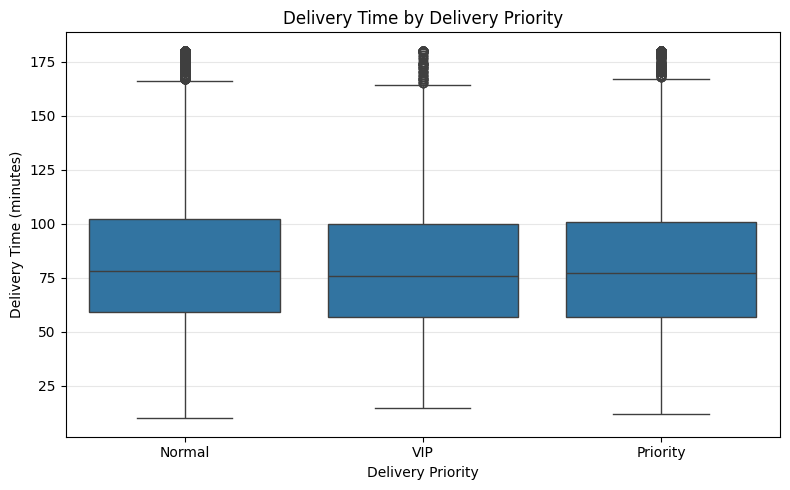

In [152]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Delivery_Priority",
    y="Time_taken_min"
)

plt.title("Delivery Time by Delivery Priority")
plt.xlabel("Delivery Priority")
plt.ylabel("Delivery Time (minutes)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



- Delivery priority appears to have a weak individual relationship with delivery time because the median delivery times for Normal, Priority, and VIP orders are very similar

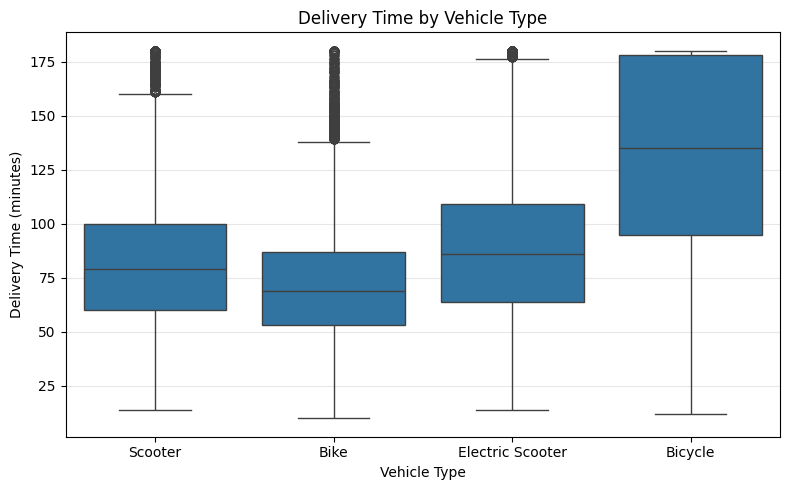

In [153]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Vehicle_Type",
    y="Time_taken_min"
)

plt.title("Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (minutes)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Bicycle has the highest median delivery time, while Bike has the lowest. Vehicle type appears to influence delivery time, with Bicycle deliveries generally taking longer than the other vehicle types.

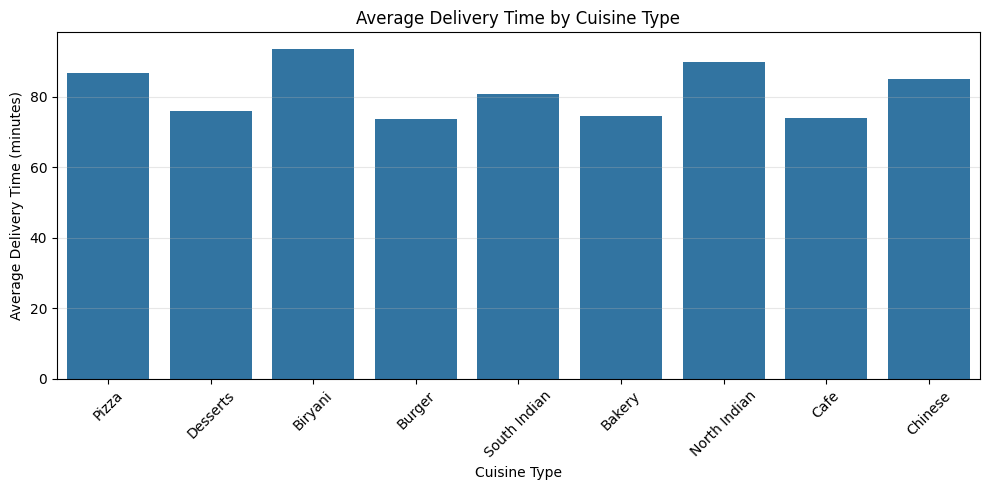

In [154]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Cuisine_Type",
    y="Time_taken_min",
    errorbar=None
)

plt.title("Average Delivery Time by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Biryani takes more preparation time.
- Dessarts takes less preparation time.

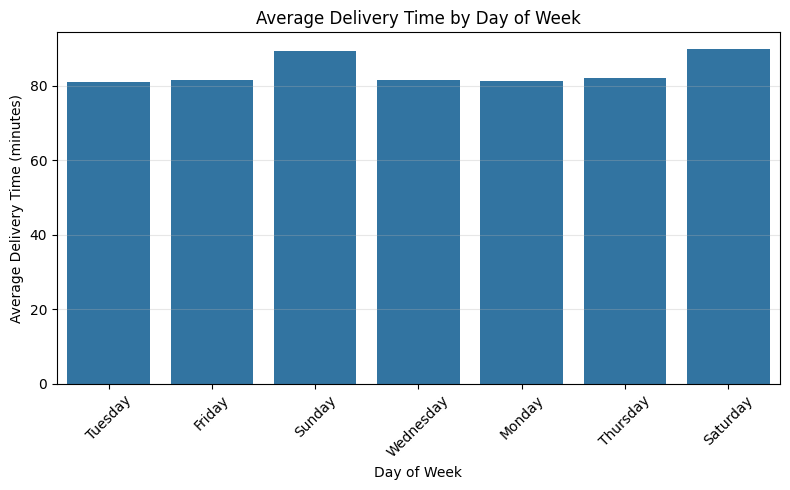

In [155]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Day_of_Week",
    y="Time_taken_min",
    errorbar=None
)

plt.title("Average Delivery Time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

- Average delivery time is fairly similar across days, with Saturday and Sunday having the highest average delivery times 90 min, while Tuesday has the lowest (81 min).

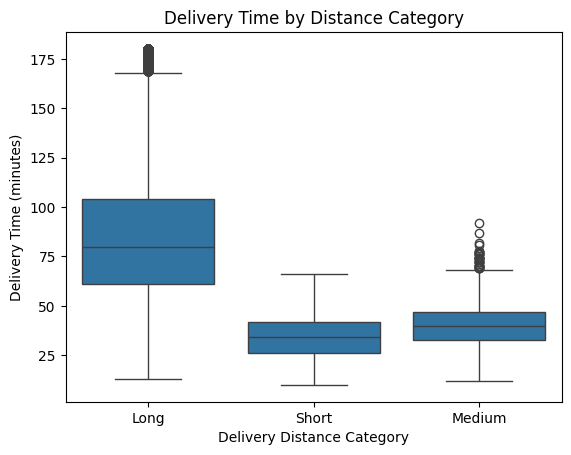

In [156]:
sns.boxplot(
    data=df,
    x='Delivery_Distance_Category',
    y='Time_taken_min'
)

plt.title('Delivery Time by Distance Category')
plt.xlabel('Delivery Distance Category')
plt.ylabel('Delivery Time (minutes)')
plt.show()

- Long distance deliveries have the highest median, while Short-distance deliveries have the lowest median and relatively narrow distribution. Medium-distance deliveries fall between the two, although they contain several higher-time outliers.

### Feature vs Feature Relation

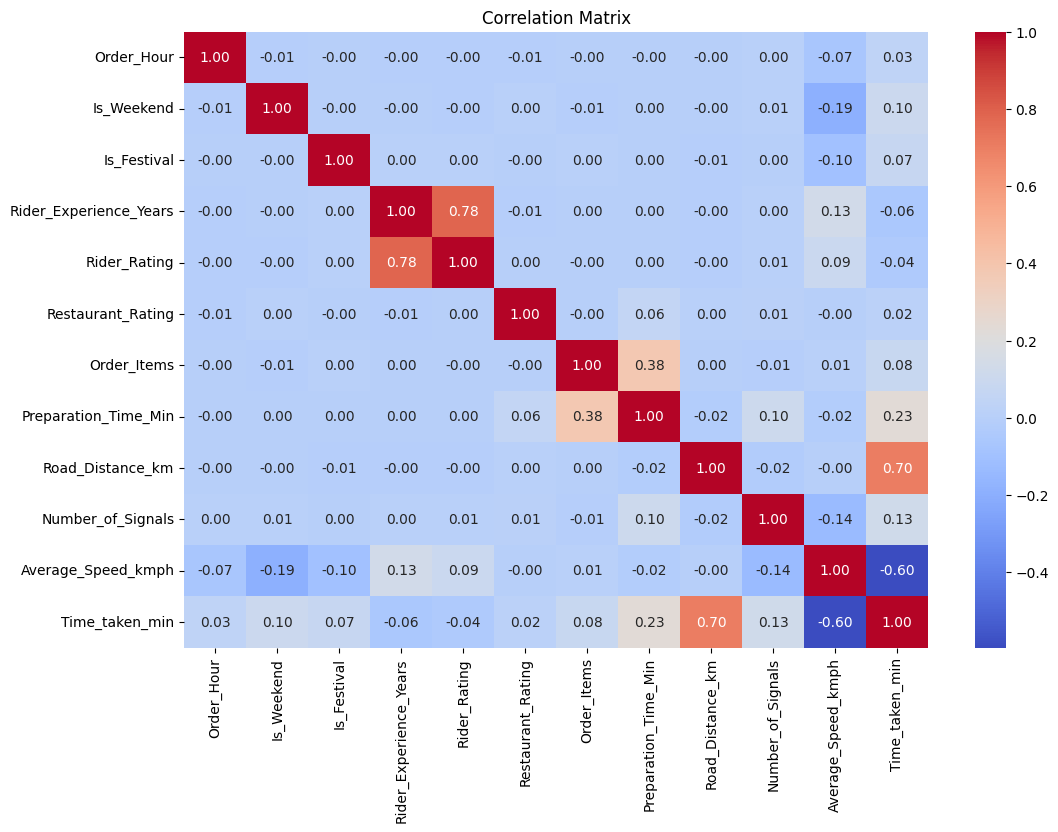

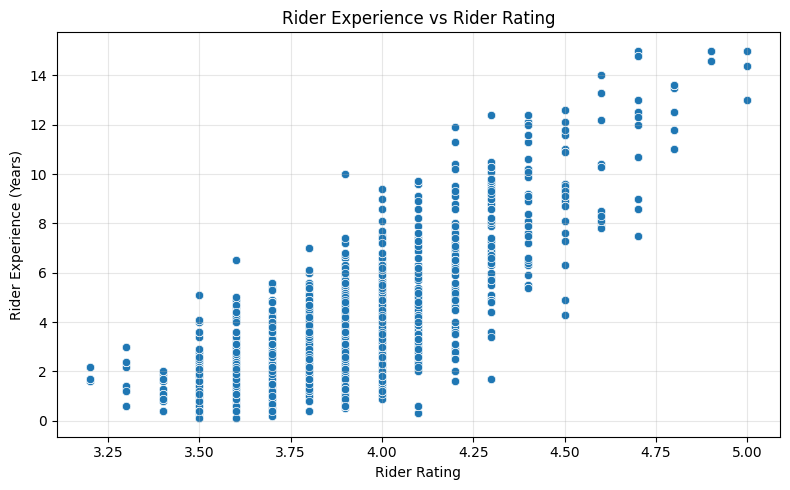

In [158]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rider_Rating",
    y="Rider_Experience_Years"
)

plt.title("Rider Experience vs Rider Rating")
plt.xlabel("Rider Rating")
plt.ylabel("Rider Experience (Years)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Rider experience and rating show a strong positive relationship. As rider experience increases, rider ratings generally increase, confirming the 0.78 correlation seen in the heatmap.

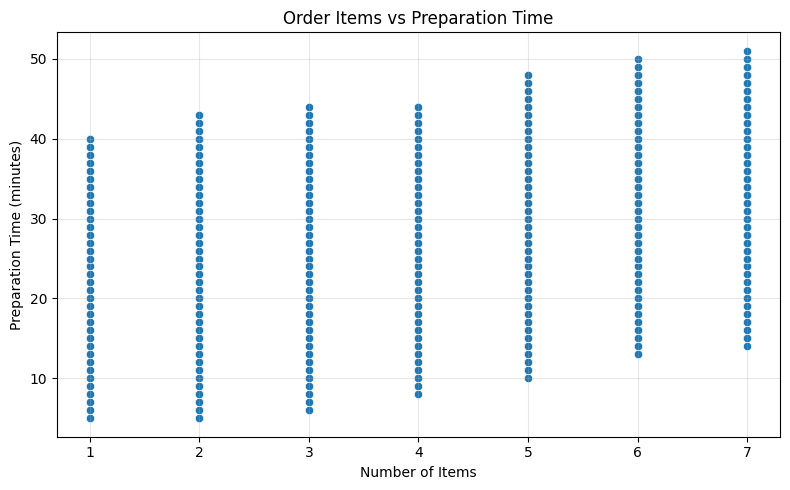

In [159]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Order_Items",
    y="Preparation_Time_Min"
)

plt.title("Order Items vs Preparation Time")
plt.xlabel("Number of Items")
plt.ylabel("Preparation Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- As the number of items increases, preparation time generally increases. The relationship is moderately positive, but there is still considerable variation at each item count.

### Categorical vs Numerical Features

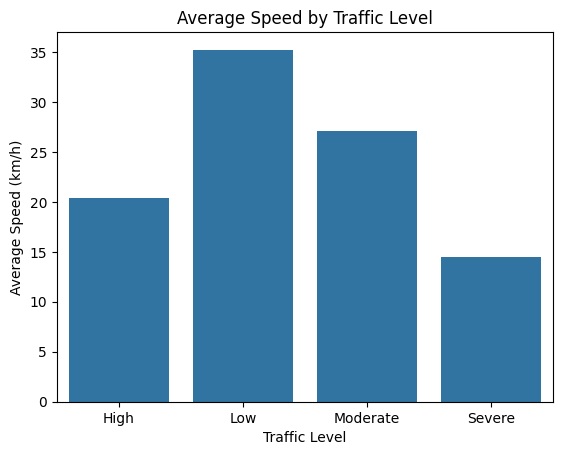

In [160]:
Avg_speed_whether=df.groupby('Traffic_Level',as_index=False)['Average_Speed_kmph'].mean()

sns.barplot(
    data=Avg_speed_whether,
    x='Traffic_Level',
    y='Average_Speed_kmph'
)

plt.title('Average Speed by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Average Speed (km/h)')
plt.show()

- Average speed decreases as traffic severity increases. Low traffic has the highest average speed, while Severe traffic has the lowest, showing that heavier traffic significantly reduces delivery speed.

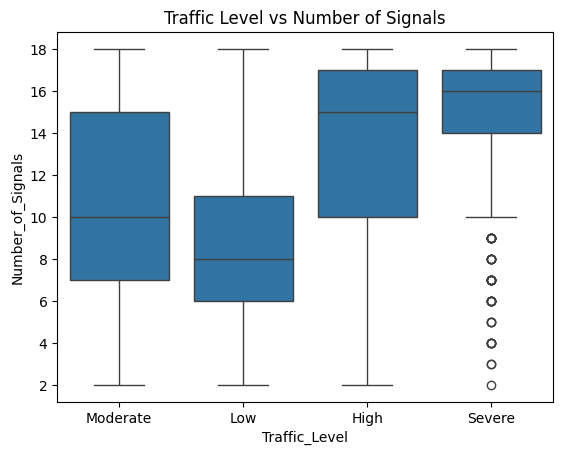

In [161]:
df.groupby('Traffic_Level')['Number_of_Signals'].agg(
    ['count', 'mean', 'median', 'std']
)
sns.boxplot(
    data=df,
    x='Traffic_Level',
    y='Number_of_Signals'
)

plt.title('Traffic Level vs Number of Signals')
plt.show()

- Higher traffic levels are associated with a higher number of signals. Severe traffic has the highest median number of signals, while Low traffic has the lowest, suggesting that more signals may contribute to increased traffic and delays.

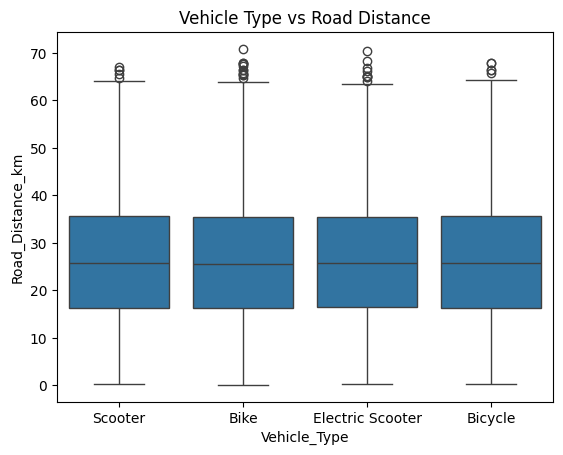

In [162]:
df.groupby('Vehicle_Type')['Road_Distance_km'].agg(
    ['count', 'mean', 'median', 'std']
).sort_values('median')
sns.boxplot(
    data=df,
    x='Vehicle_Type',
    y='Road_Distance_km'
)

plt.title('Vehicle Type vs Road Distance')
plt.show()

- Vehicle types have very similar road-distance distributions, with nearly identical medians and IQRs. Therefore, vehicle type does not appear to have a meaningful relationship with road distance.

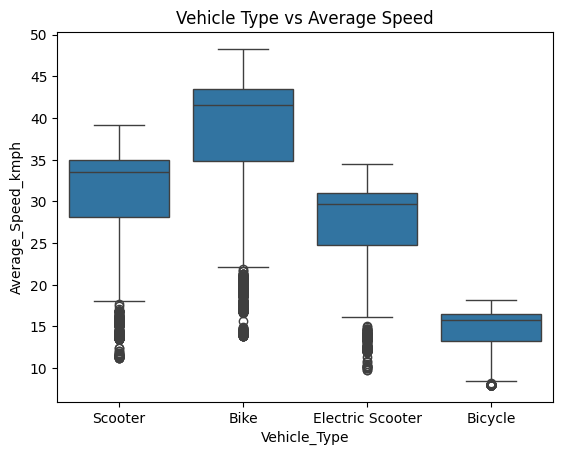

In [163]:
df.groupby('Vehicle_Type')['Average_Speed_kmph'].agg(
    ['count', 'mean', 'median', 'std']
)
sns.boxplot(
    data=df,
    x='Vehicle_Type',
    y='Average_Speed_kmph'
)

plt.title('Vehicle Type vs Average Speed')
plt.show()

- Vehicle type shows a strong difference in average speed. Bikes have the highest median speed, while Bicycles have the lowest; Scooters and Electric Scooters fall in between.

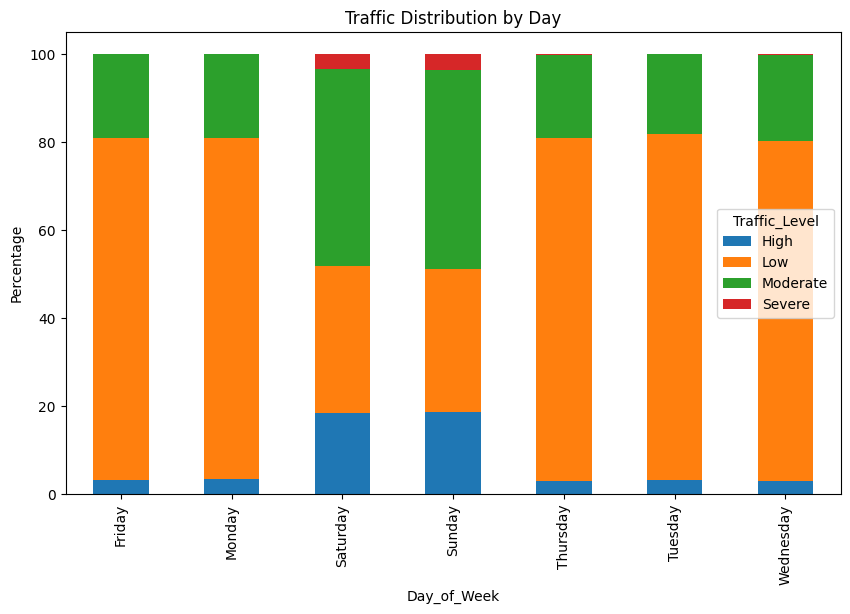

In [164]:
traffic_day = pd.crosstab(
    df['Day_of_Week'],
    df['Traffic_Level'],
    normalize='index'
) * 100

traffic_day.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Percentage')
plt.title('Traffic Distribution by Day')
plt.show()

- Traffic levels vary by day. Saturday and Sunday have noticeably higher High/Moderate traffic, while weekdays are dominated by Low traffic. Severe traffic is very rare overall and appears mainly on weekends.

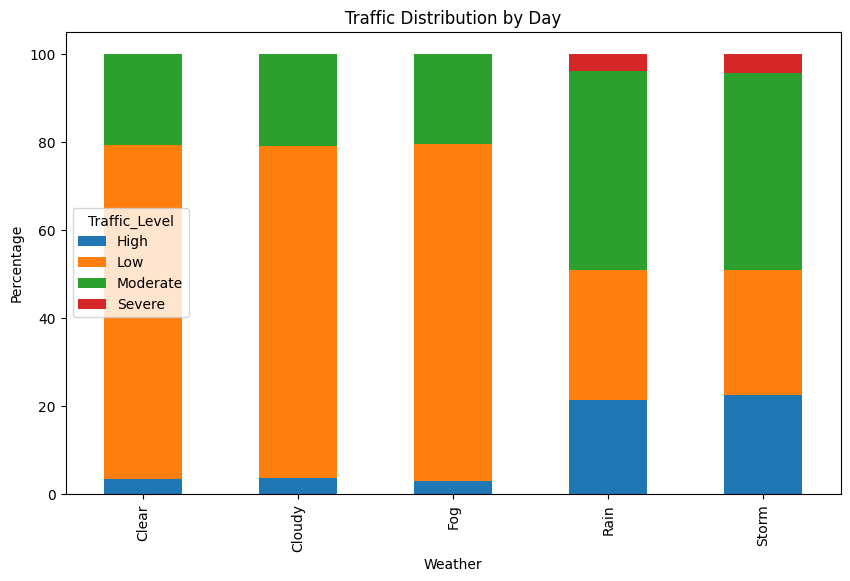

In [165]:
whether_traffic=pd.crosstab(
    df['Weather'],
    df['Traffic_Level'],
    normalize='index'
) * 100
whether_traffic.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Percentage')
plt.title('Traffic Distribution by Day')
plt.show()

- Rain and Storm show the highest levels of High and Moderate traffic, while Clear, Cloudy, and Fog are dominated by Low traffic. Severe traffic is mainly observed during Rain and Storm conditions, indicating that poor weather is associated with heavier traffic.

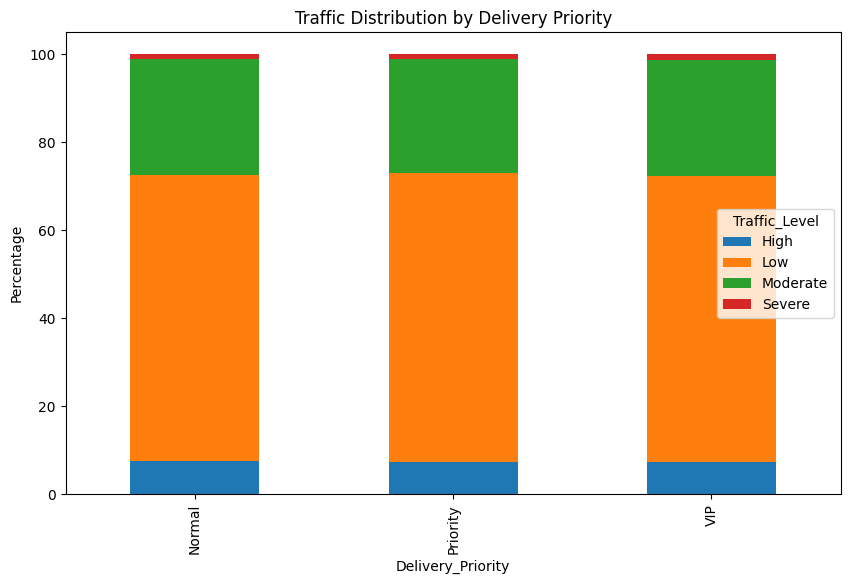

In [166]:
priority_traffic=pd.crosstab(
    df['Delivery_Priority'],
    df['Traffic_Level'],
    normalize='index'
) * 100
priority_traffic.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)
plt.title("Traffic Distribution by Delivery Priority")
plt.ylabel('Percentage')

plt.show()

- It shows that traffic distribution is very similar across Normal, Priority, and VIP orders, so Delivery Priority does not appear to have a strong relationship with Traffic Level.

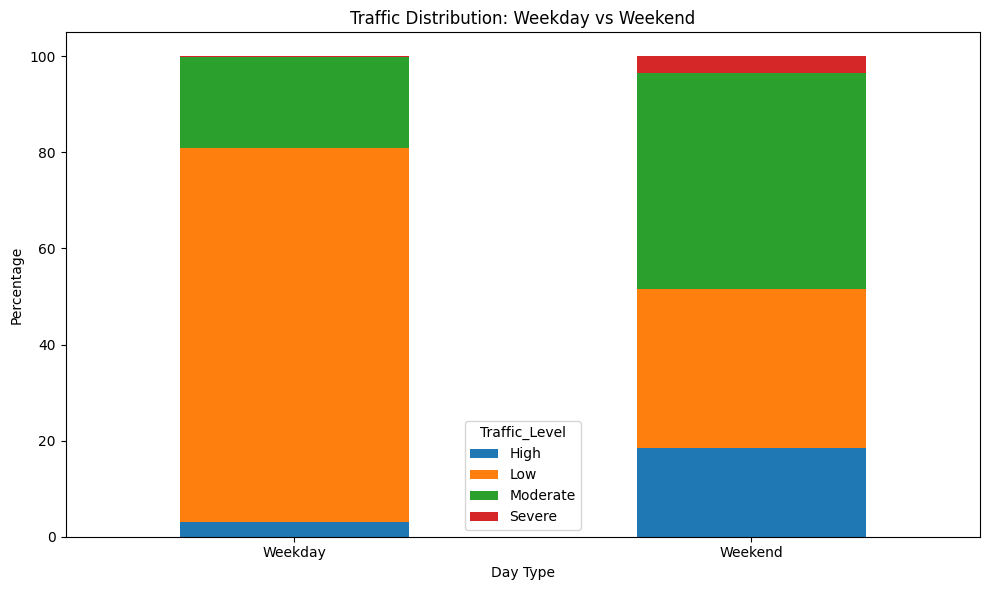

In [167]:
weekend_traffic = pd.crosstab(
    df["Is_Weekend"],
    df["Traffic_Level"],
    normalize="index"
) * 100

ax = weekend_traffic.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Traffic Distribution: Weekday vs Weekend")
ax.set_xlabel("Day Type")
ax.set_ylabel("Percentage")
ax.set_xticklabels(["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.show()

- Weekends show a much higher share of High, Moderate, and Severe traffic, while weekdays are dominated by Low traffic.
- This indicates weekends are associated with heavier traffic conditions.

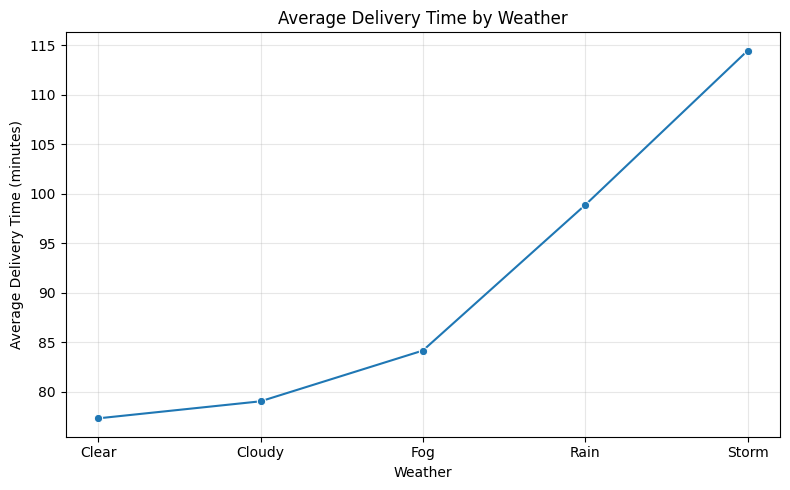

In [189]:
avg_weather_del_time = df.groupby("Weather")["Time_taken_min"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    x=avg_weather_del_time.index,
    y=avg_weather_del_time["mean"],
    marker="o"
)

plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (minutes)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Average delivery time increases consistently from Clear to Storm. Storm has the highest average (~115 min).
- while Clear has the lowest (~77 min), indicating that worsening weather is strongly associated with longer delivery times.

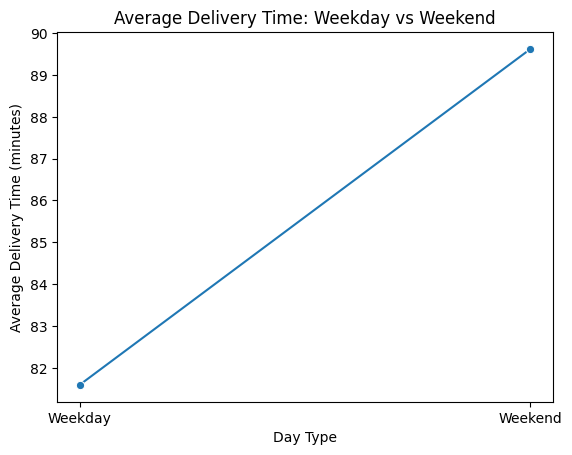

In [169]:
weekend_time = df.groupby('Is_Weekend')['Time_taken_min'].mean()

sns.lineplot(
    x=weekend_time.index,
    y=weekend_time.values,
    marker='o'
)

plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.xlabel('Day Type')
plt.ylabel('Average Delivery Time (minutes)')
plt.title('Average Delivery Time: Weekday vs Weekend')
plt.show()

- The Average delivery time is higher in Weekends ~ 90 mins
- In weekdays, the delivery time is approximately 80 mins

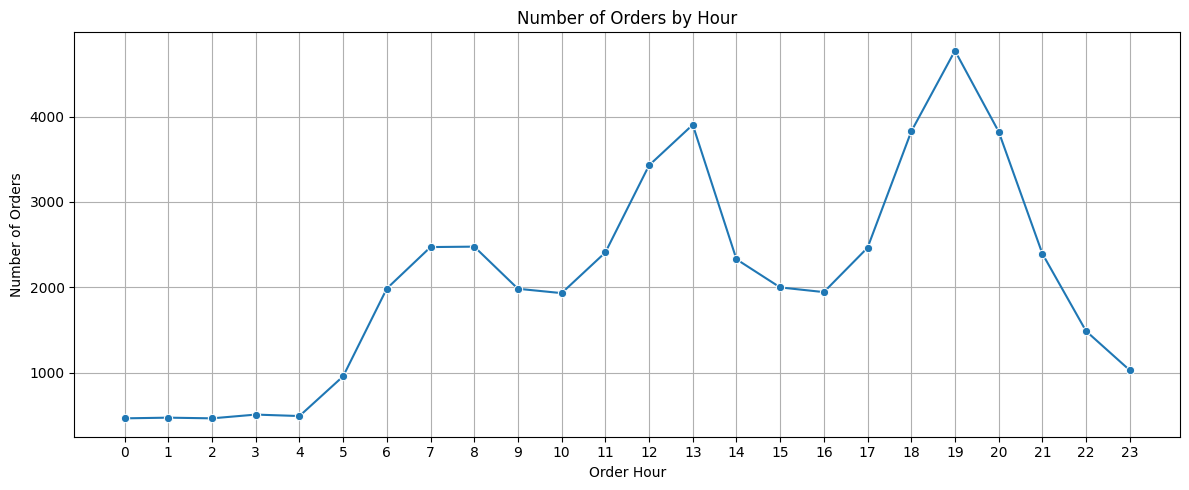

In [170]:
orders_by_hour = df.groupby('Order_Hour').size()

plt.figure(figsize=(12,5))

sns.lineplot(
    x=orders_by_hour.index,
    y=orders_by_hour.values,
    marker='o'
)

plt.title('Number of Orders by Hour')
plt.xlabel('Order Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

- Most of orders are placed at night and afternoon time during Dinner time(6pm to 9pm) and dinner time (11 am to 2pm).
- While some of the orders are placed at morning 6 am to 9 am

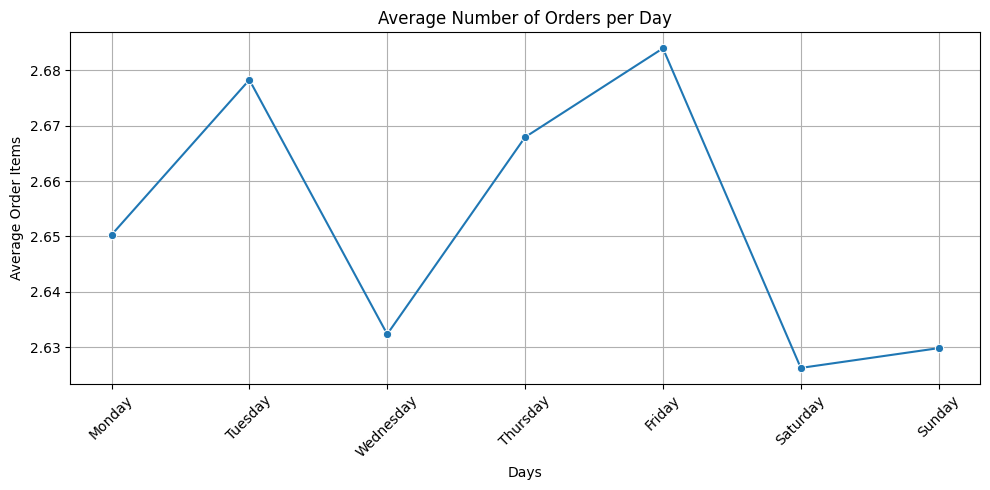

In [171]:

Avg_items_per_day = df.groupby('Day_of_Week')['Order_Items'].agg(
    ['mean', 'median', 'std', 'count', 'max']
)
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

Avg_items_per_day = Avg_items_per_day.reindex(day_order)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=Avg_items_per_day.index,
    y=Avg_items_per_day['mean'],
    marker='o'
)

plt.title('Average Number of Orders per Day')
plt.xlabel('Days')
plt.ylabel('Average Order Items')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

- On a Average of 2 Items per order are ordered every Day in a week.
- Weekday orders generally have a higher average number of items compared with weekend orders.

<Axes: xlabel='Road_Distance_km', ylabel='Time_taken_min'>

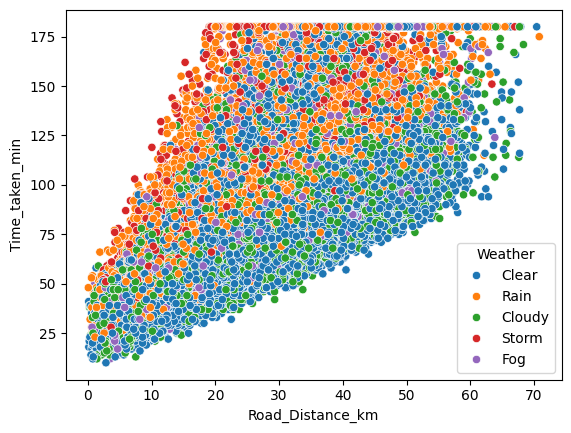

In [172]:
sns.scatterplot(
    data=df,
    x='Road_Distance_km',
    y='Time_taken_min',
    hue='Weather'
)

- When the weather condition is Clear, the delivery time depends on the distance.
- But when the weather is rainy or stroming conditions the delivery time is high compared to normal delivery time.

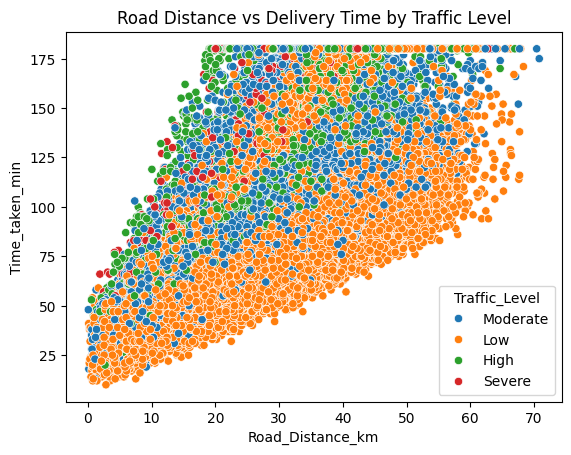

In [173]:
sns.scatterplot(
    data=df,
    x='Road_Distance_km',
    y='Time_taken_min',
    hue='Traffic_Level'
)

plt.title('Road Distance vs Delivery Time by Traffic Level')
plt.show()

- Road distance shows a clear positive relationship with delivery time. Traffic level appears to further influence delivery time, with lower traffic generally associated with shorter delivery times and higher traffic associated with longer delivery times.

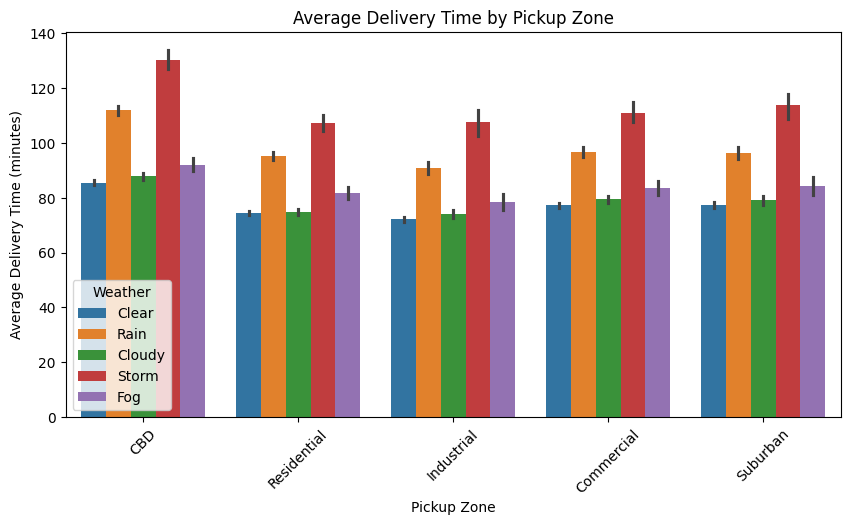

In [174]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='Pickup_Zone',
    y='Time_taken_min',
    hue='Weather'
)

plt.title('Average Delivery Time by Pickup Zone')
plt.xlabel('Pickup Zone')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.show()

- Average delivery time varies across both pickup zones and weather conditions. Storm conditions consistently show the highest delivery times, while Clear and Cloudy conditions generally have lower delivery times. CBD has comparatively higher delivery times across most weather conditions, indicating a possible interaction between pickup location and weather conditions.

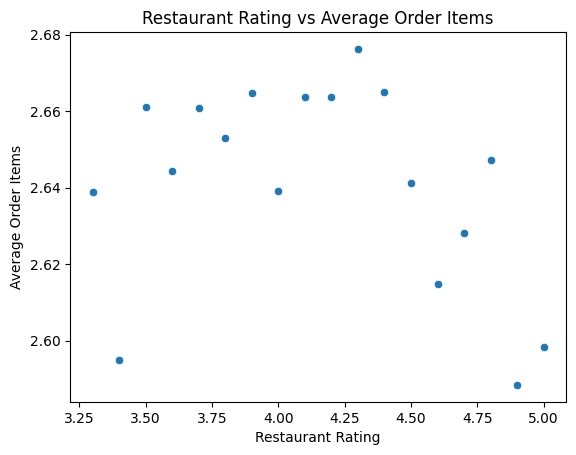

In [175]:
rating_items = df.groupby(
    'Restaurant_Rating',
    as_index=False
)['Order_Items'].mean()

sns.scatterplot(
    data=rating_items,
    x='Restaurant_Rating',
    y='Order_Items'
)

plt.title('Restaurant Rating vs Average Order Items')
plt.xlabel('Restaurant Rating')
plt.ylabel('Average Order Items')
plt.show()

- The average number of items remains relatively stable across restaurant ratings, with only small fluctuations.

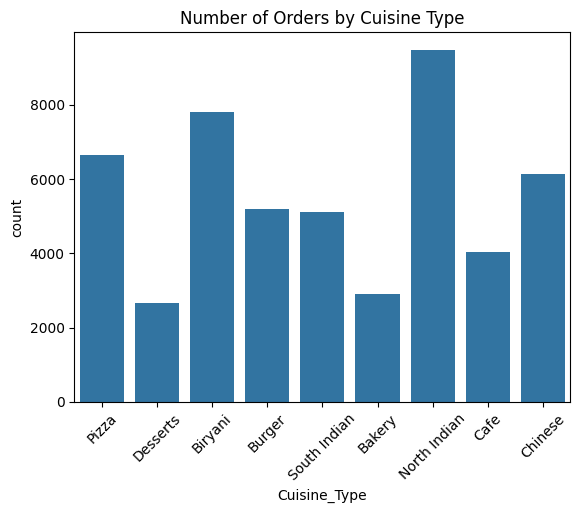

In [176]:
sns.countplot(
    data=df,
    x='Cuisine_Type'
)

plt.xticks(rotation=45)
plt.title('Number of Orders by Cuisine Type')
plt.show()

- North Indian cuisine has the highest order volume, followed by Biryani and Pizza, while Desserts and Bakery have the lowest order volumes. This indicates considerable variation in customer demand across cuisine types.

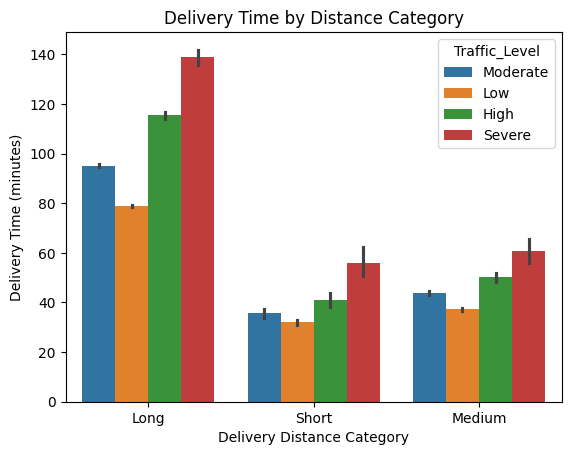

In [177]:
sns.barplot(
    data=df,
    x='Delivery_Distance_Category',
    y='Time_taken_min',
    hue='Traffic_Level'
)

plt.title('Delivery Time by Distance Category')
plt.xlabel('Delivery Distance Category')
plt.ylabel('Delivery Time (minutes)')
plt.show()

- Average delivery time increases consistently with both delivery distance and traffic severity. Within every distance category, Severe traffic has the highest average delivery time and Low traffic has the lowest. Long-distance deliveries remain the slowest across all traffic levels, indicating that distance and traffic both contribute to differences in delivery time.

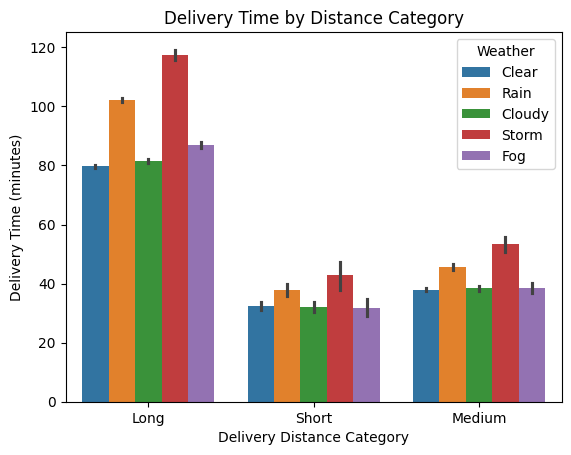

In [178]:
sns.barplot(
    data=df,
    x='Delivery_Distance_Category',
    y='Time_taken_min',
    hue='Weather'
)

plt.title('Delivery Time by Distance Category')
plt.xlabel('Delivery Distance Category')
plt.ylabel('Delivery Time (minutes)')
plt.show()

- Average delivery time varies with both delivery distance and weather. Long-distance deliveries consistently require more time than Short and Medium deliveries, while Storm and Rain conditions are associated with substantially higher delivery times across all distance categories. The combination of Long distance and Storm weather has the highest average delivery time.

- Average Preparation time during festivals and non feativals are Similar.

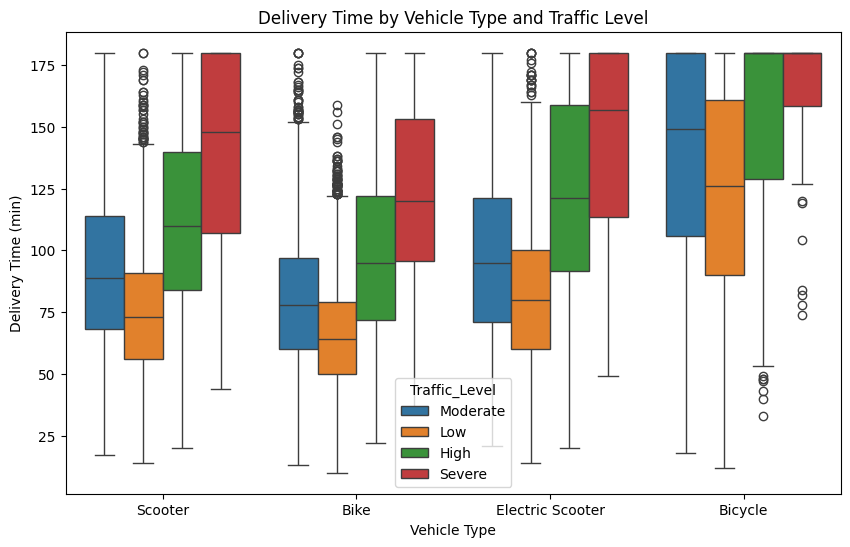

In [179]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Vehicle_Type',
    y='Time_taken_min',
    hue='Traffic_Level'
)

plt.title('Delivery Time by Vehicle Type and Traffic Level')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Time (min)')
plt.show()

- Delivery time generally increases as traffic severity increases across vehicle types. Severe traffic produces the highest delivery times, while Low traffic generally has the lowest. The effect is especially noticeable for Electric Scooters and Bicycles.

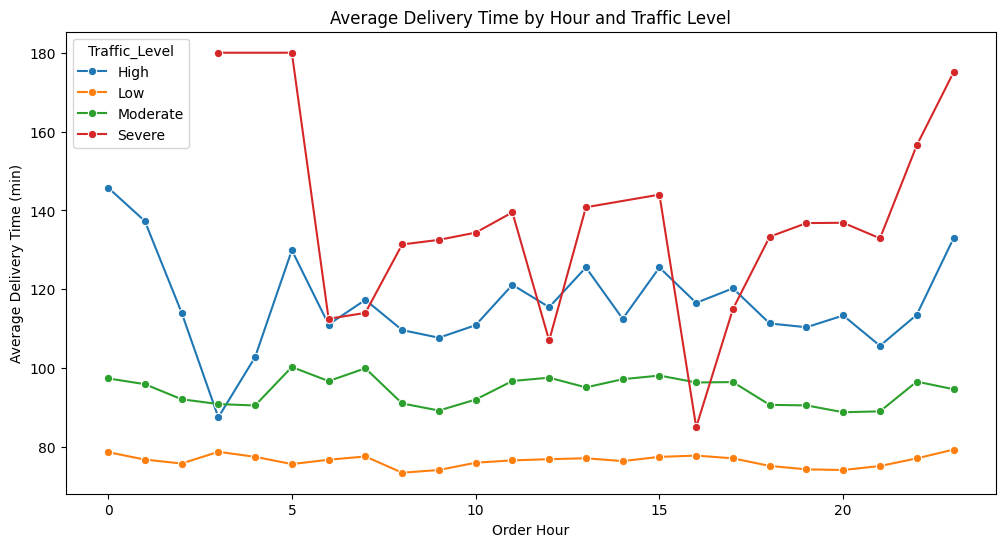

In [180]:
hour_traffic_time = (
    df.groupby(['Order_Hour', 'Traffic_Level'])['Time_taken_min']
      .mean()
      .reset_index()
)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hour_traffic_time,
    x='Order_Hour',
    y='Time_taken_min',
    hue='Traffic_Level',
    marker='o'
)

plt.title('Average Delivery Time by Hour and Traffic Level')
plt.xlabel('Order Hour')
plt.ylabel('Average Delivery Time (min)')
plt.show()

- Delivery time varies substantially by traffic level across different hours. Severe traffic generally has the highest delivery times, while Low traffic remains consistently lowest; the effect is especially large during certain hours.

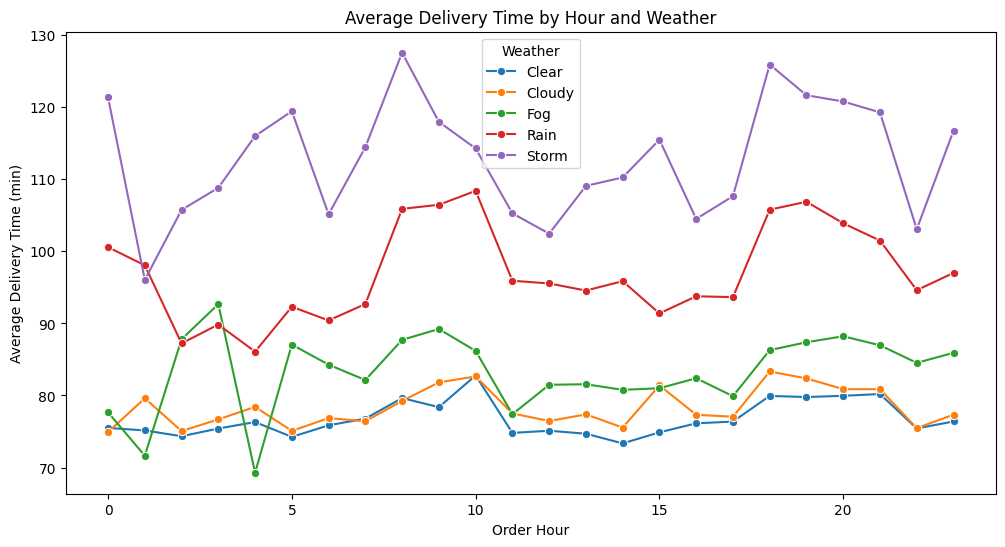

In [181]:
hour_weather_time = (
    df.groupby(['Order_Hour', 'Weather'])['Time_taken_min']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hour_weather_time,
    x='Order_Hour',
    y='Time_taken_min',
    hue='Weather',
    marker='o'
)

plt.title('Average Delivery Time by Hour and Weather')
plt.xlabel('Order Hour')
plt.ylabel('Average Delivery Time (min)')
plt.show()

- Storm consistently has the highest delivery times, while Clear and Cloudy are generally the lowest. Rain also causes noticeably higher delivery times, especially during certain hours, showing that weather impact varies across the day.

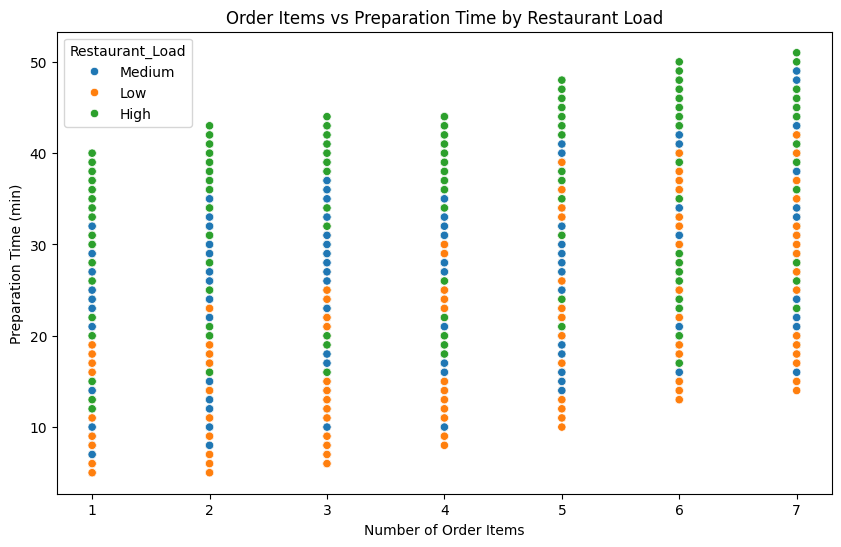

In [182]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Order_Items',
    y='Preparation_Time_Min',
    hue='Restaurant_Load'
)

plt.title('Order Items vs Preparation Time by Restaurant Load')
plt.xlabel('Number of Order Items')
plt.ylabel('Preparation Time (min)')
plt.show()

- As the number of order items increases, preparation time generally increases across all restaurant-load levels. High restaurant load tends to show higher preparation times, while Low load generally has lower preparation times. This suggests that order size and restaurant load together influence preparation time.

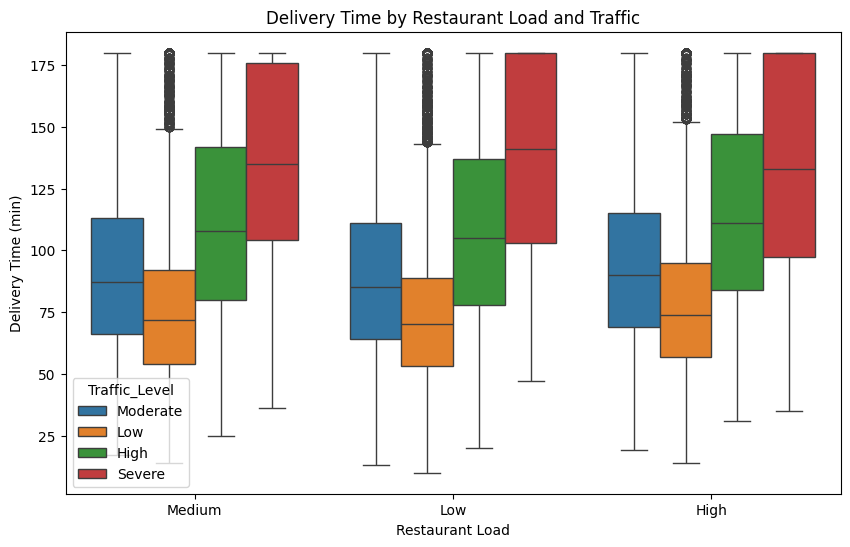

In [183]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Restaurant_Load',
    y='Time_taken_min',
    hue='Traffic_Level'
)

plt.title('Delivery Time by Restaurant Load and Traffic')
plt.xlabel('Restaurant Load')
plt.ylabel('Delivery Time (min)')
plt.show()

- Delivery time increases strongly with traffic severity across all restaurant-load levels. Restaurant load itself shows a smaller effect compared with traffic, suggesting traffic is the dominant factor, while restaurant load has a secondary influence.

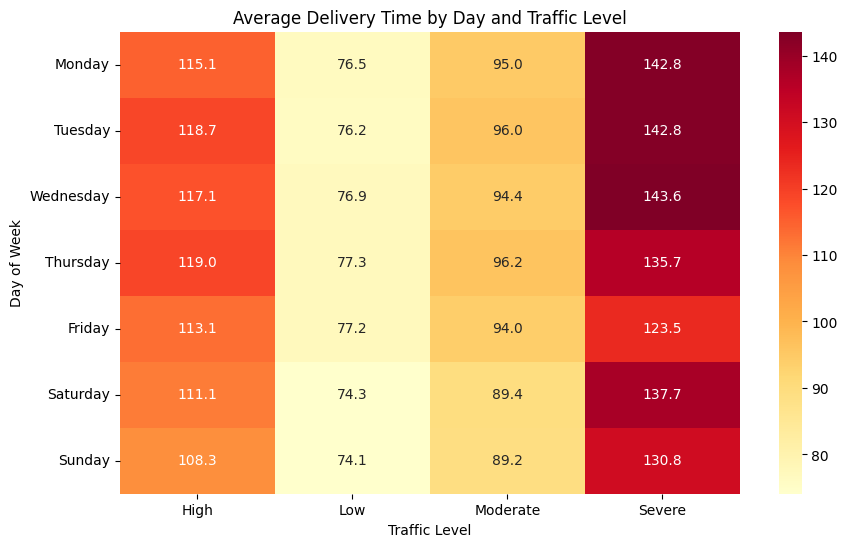

In [184]:
day_traffic_time = pd.pivot_table(
    df,
    values='Time_taken_min',
    index='Day_of_Week',
    columns='Traffic_Level',
    aggfunc='mean'
)

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_traffic_time = day_traffic_time.reindex(day_order)
plt.figure(figsize=(10,6))

sns.heatmap(
    day_traffic_time,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Average Delivery Time by Day and Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Day of Week')
plt.show()

- Delivery time is consistently highest under Severe traffic and lowest under Low traffic across all days. Severe-traffic deliveries are especially high on Monday–Wednesday, while overall delivery times tend to be lower on weekends.

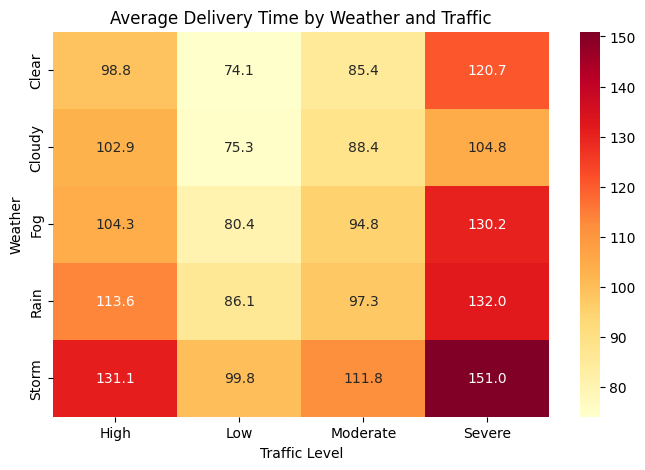

In [185]:
weather_traffic_time = pd.pivot_table(
    df,
    values='Time_taken_min',
    index='Weather',
    columns='Traffic_Level',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    weather_traffic_time,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Average Delivery Time by Weather and Traffic')
plt.xlabel('Traffic Level')
plt.ylabel('Weather')
plt.show()

- Delivery time increases with both worsening weather and higher traffic. Storm + Severe traffic has the highest average , while Clear + Low traffic has the lowest , showing a combined effect of weather and traffic on delivery time.

In [186]:
worst_conditions = (
    df.groupby(
        ['Traffic_Level',
         'Weather',
         'Delivery_Distance_Category']
    )['Time_taken_min']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
    .query("count >= 50")
)

worst_conditions.head(10)

count        mean  median  \
Traffic_Level Weather Delivery_Distance_Category                              
Severe        Storm   Long                          103  153.398058   177.0   
              Rain    Long                          343  136.868805   137.0   
High          Storm   Long                          525  134.076190   134.0   
              Rain    Long                         1820  117.648352   114.0   
Moderate      Storm   Long                         1036  115.130309   111.5   
High          Fog     Long                           95  108.305263   101.0   
              Cloudy  Long                          368  105.706522   100.5   
Low           Storm   Long                          658  102.586626    98.0   
Moderate      Rain    Long                         3862  100.504143    96.0   
High          Clear   Long                          733  102.114598    96.0   

                                                        std  
Traffic_Level Weather Delivery_Distance_Category             
Severe        Storm   Long                        33.959705  
              Rain    Long                        35.599178  
High          Storm   Long                        37.729879  
              Rain    Long                        38.231514  
Moderate      Storm   Long                        37.871706  
High          Fog     Long                        38.150339  
              Cloudy  Long                        35.110037  
Low           Storm   Long                        36.957122  
Moderate      Rain    Long                        35.008858  
High          Clear   Long                        34.746788

- The Severe Traffic + Storm + Long-distance segment shows the highest observed typical delivery time among the analyzed segments, although its sample size is relatively small.

In [187]:
peak_segments = (
    df.groupby(
        ['Order_Hour',
         'Traffic_Level',
         'Delivery_Distance_Category']
    )['Time_taken_min']
    .agg(['count', 'mean', 'median'])
    .query('count >= 50')
    .sort_values('median', ascending=False)
)

peak_segments.head(15)

,,,count,mean,median
Order_Hour,Traffic_Level,Delivery_Distance_Category,,,
9,Severe,Long,53,137.886792,144.0
21,Severe,Long,59,139.983051,142.0
19,Severe,Long,112,141.116071,142.0
18,Severe,Long,85,136.152941,138.0
20,Severe,Long,69,138.927536,138.0
8,Severe,Long,55,135.872727,130.0
12,High,Long,63,121.809524,127.0
13,High,Long,85,128.117647,126.0
11,High,Long,54,124.055556,120.5


- This grouping reveals high-impact combinations. Severe + Long distance has the highest average delivery times, especially around 19–21 hours . High + Long distance also shows elevated delivery times, particularly around 11–13 hours. Smaller groups should be interpreted cautiously because of low sample counts.

In [188]:
restaurant_segments = (
    df.groupby(
        ['Restaurant_Load', 'Delivery_Distance_Category']
    )['Time_taken_min']
    .agg(['count', 'mean', 'median'])
    .query('count >= 50')
    .sort_values('median', ascending=False)
)

restaurant_segments

,,count,mean,median
Restaurant_Load,Delivery_Distance_Category,,,
High,Long,14907,88.755417,82.0
Medium,Long,15568,86.149923,80.0
Low,Long,16763,84.809342,78.0
High,Medium,700,42.631429,42.0
Medium,Medium,731,39.543092,39.0
Low,Medium,804,38.601990,38.5
High,Short,192,36.348958,37.0
Medium,Short,151,33.635762,35.0
Low,Short,184,30.918478,32.0


- Delivery time is strongly driven by distance category: Long-distance deliveries take much longer than Medium and Short. Within each distance category, High restaurant load has the highest average delivery time, but the difference is much smaller than the effect of distance.



---



# Insights

- As delivery distance increases, delivery time generally increases.
- Delivery time increases consistently from Low → Moderate → High → Severe traffic.

- Severe traffic produces the highest delivery times across almost every analyzed segment.

- Higher average speed is associated with shorter delivery times.
- Order size and restaurant workload together are associated with longer preparation times, which can increase total delivery time.

- Storm + Severe Traffic produces the highest average delivery times.

- Clear + Low Traffic produces the lowest delivery times.
- Distance and traffic have a combined effect on delivery time, with long-distance deliveries under severe traffic experiencing the greatest delays.

- Long-distance deliveries take longer.
- Rain increases delivery time.
- Storm increases delivery time even more.

- Severe + Long-distance deliveries have particularly high delivery times around 19:00–21:00.
- Weather-related delays are not uniform throughout the day; their impact varies depending on the order hour.
- Average order size remains relatively stable across restaurant ratings.
- CBD has comparatively higher delivery times across most weather conditions.